Python Basics and QCM Calculations

In [1]:
crystal_frequency = 5e6

In [2]:
print(crystal_frequency)

5000000.0


In [3]:
#coating mass calculation

coating_shift = -85 # measured Δf in Hz
mass_per_hz = 17.7 #ng/cm2 per Hz, Sauerbrey constant for 5 MHz crystal, this constant represents the mass change (delta m) per unit area

coating_mass = abs(coating_shift) * mass_per_hz

print(f"Estimated coating mass: {coating_mass} ng/cm2")

Estimated coating mass: 1504.5 ng/cm2


In [4]:
#overtones and corresponding frequencies

overtones = [1,3,5,7]

for n in overtones:
    print(f"Overtone {n}: frequency = {n*5} Hz")

Overtone 1: frequency = 5 Hz
Overtone 3: frequency = 15 Hz
Overtone 5: frequency = 25 Hz
Overtone 7: frequency = 35 Hz


In [5]:
#delta f calculation for each overtones

for n in overtones:
    scaled_shift = -85 * n
    print(f"n={n}: expected delta_f: {scaled_shift} Hz")

n=1: expected delta_f: -85 Hz
n=3: expected delta_f: -255 Hz
n=5: expected delta_f: -425 Hz
n=7: expected delta_f: -595 Hz


NumPy Introduction,
Arrays instead of lists

In [6]:
import numpy as np

In [7]:
time = np.linspace(0, 300, 300).round(2)
print(f"First 5 values: {time[:5]}")
print(f"last 5 values: {time[-5:]}")
print(f"Total points: {len(time)}")

First 5 values: [0.   1.   2.01 3.01 4.01]
last 5 values: [295.99 296.99 297.99 299.   300.  ]
Total points: 300


In [8]:
# math on the whole array at once

time_minutes = time / 60
print(f"In minutes: {time_minutes.round(2)[:5]}")

In minutes: [0.   0.02 0.03 0.05 0.07]


Random noise

In [9]:
noise = np.random.normal(0, 0.5, 300)
print(f"Noise range: {noise.min(): .2f} to {noise.max(): .2f} Hz")
print(f"Average (should be near zero): {noise.mean():.4f} Hz")

baseline = np.zeros(300) + noise # 300 zeros + random noise

Noise range: -1.38 to  1.66 Hz
Average (should be near zero): 0.0304 Hz


The exponential function

When molecules land on the surface, binding is fast at first, then slows

This is described by: signal = final_value * ( 1 - exp(-time / tau)) (Pseudo-First-Order)

In [10]:
tau = 180 #time constant in seconds (how fast adsorption happens)
final_value = -85 #final frequency shift in Hz

#calculation of adsorption curve
adsorption = final_value * (1 - np.exp(-time/tau))

print(f"At t=0: {adsorption[0]: .1f} Hz")
print(f"At t=tau ({tau}s): {adsorption[180]: .1f} Hz")
print(f"At t=300s: {adsorption[-1]:.1f} Hz")

At t=0: -0.0 Hz
At t=tau (180s): -53.8 Hz
At t=300s: -68.9 Hz


Plotting the exponential adsorption curve

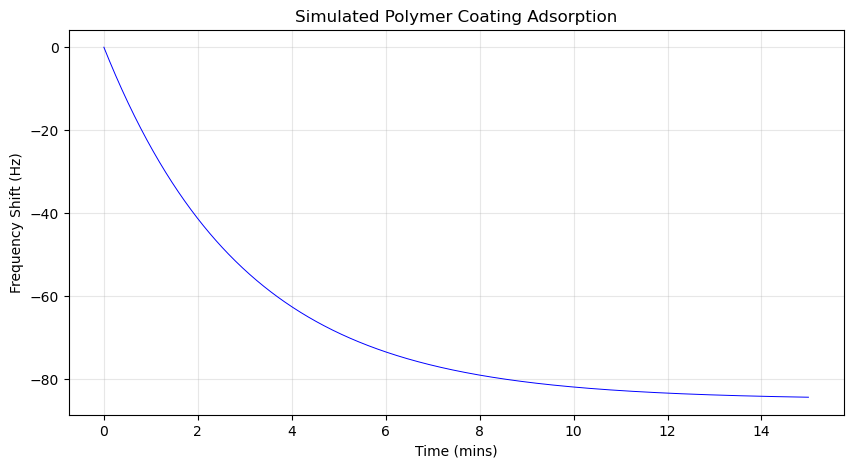

In [11]:
import matplotlib.pyplot as plt

time = np.linspace(0, 900, 900) # 900s is 15 mins
tau = 180
adsorption = -85 * (1 - np.exp(-time/tau))

#plot
plt.figure(figsize=(10,5))
plt.plot(time/60, adsorption, linewidth = 0.7, color='blue')
plt.xlabel('Time (mins)')
plt.ylabel('Frequency Shift (Hz)')
plt.title('Simulated Polymer Coating Adsorption')
plt.grid(True, alpha = 0.3)
plt.show()

Adding noise

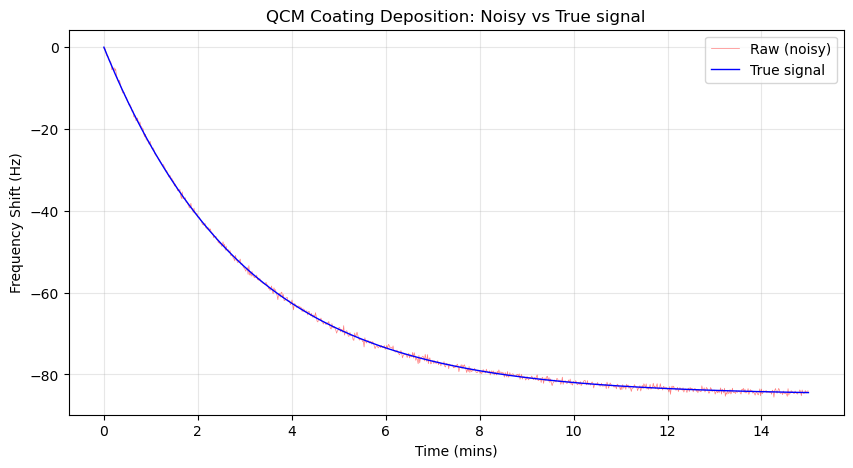

In [12]:
noise = np.random.normal(0, 0.5, 900)
noisy_adsorption = adsorption + noise

plt.figure(figsize = (10,5))
plt.plot(time / 60, noisy_adsorption, color = 'red', alpha = 0.5, linewidth = 0.5, label = 'Raw (noisy)')
plt.plot(time / 60, adsorption, color = 'blue', linewidth = 1, label = 'True signal')
plt.xlabel('Time (mins)')
plt.ylabel('Frequency Shift (Hz)')
plt.title('QCM Coating Deposition: Noisy vs True signal')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

Plotting multiple overtones

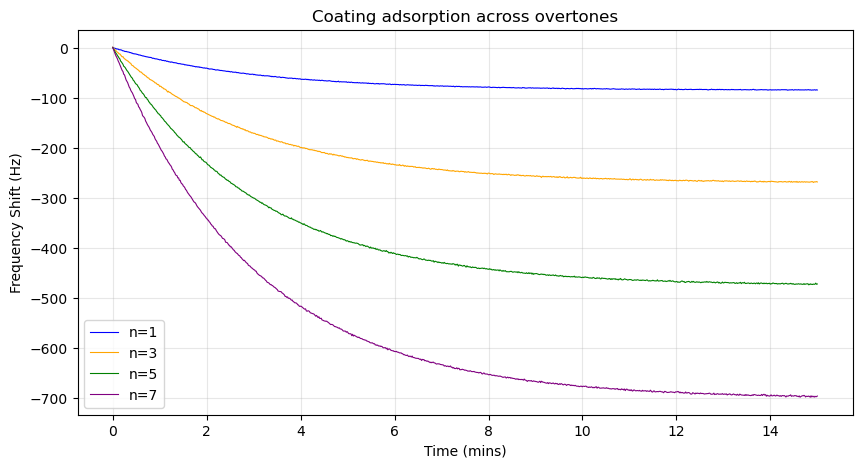

In [22]:
plt.figure(figsize=(10,5))

colors = {1: 'blue', 3: 'orange', 5: 'green', 7: 'purple'} #dictionary, color assignment to each overtones
overtones = [1,3, 5, 7]

for n in overtones:
    scale = n * (1 + 0.03 * (n-1)) #scaling factor calculation, 3% since the polymer film is viscoelastic
    signal = -85 * scale * (1 - np.exp(-time/tau))
    noise = np.random.normal(0, 0.3 * np.sqrt(n), 900) # Q-Sense QCM-D typical noise: ~0.3 Hz on fundamental, scales with sqrt(n)
    plt.plot(time / 60, signal + noise, color=colors[n], label=f'n={n}', linewidth = 0.8)

plt.xlabel("Time (mins)")
plt.ylabel("Frequency Shift (Hz)")
plt.title("Coating adsorption across overtones")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()